# 05. Evaluación e interpretación

## Objetivo
Evaluar comparativamente los modelos entrenados, seleccionar el modelo con mejor desempeño para el problema planteado e interpretar sus resultados mediante métricas, matrices de confusión, curvas ROC e importancia de variables.

In [14]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

models = {
    "Regresión Logística": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
    "Árbol de Decisión": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42))
    ]),
    
    "KNN": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ])
}

In [4]:
results = []
predictions = {}
probabilities = {}
classification_reports = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    predictions[name] = y_pred
    probabilities[name] = y_prob
    classification_reports[name] = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False).reset_index(drop=True)

display(Markdown("## Comparación final de modelos"))
display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
    .background_gradient(subset=["Recall", "F1-score", "ROC-AUC"], cmap="Blues")
)

## Comparación final de modelos

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.8445,0.8578,0.8804,0.8689,0.9188
1,KNN,0.8267,0.8303,0.8849,0.8568,0.8888
2,Random Forest,0.8237,0.8211,0.8935,0.8558,0.9076
3,Árbol de Decisión,0.8206,0.8357,0.8635,0.8494,0.8908


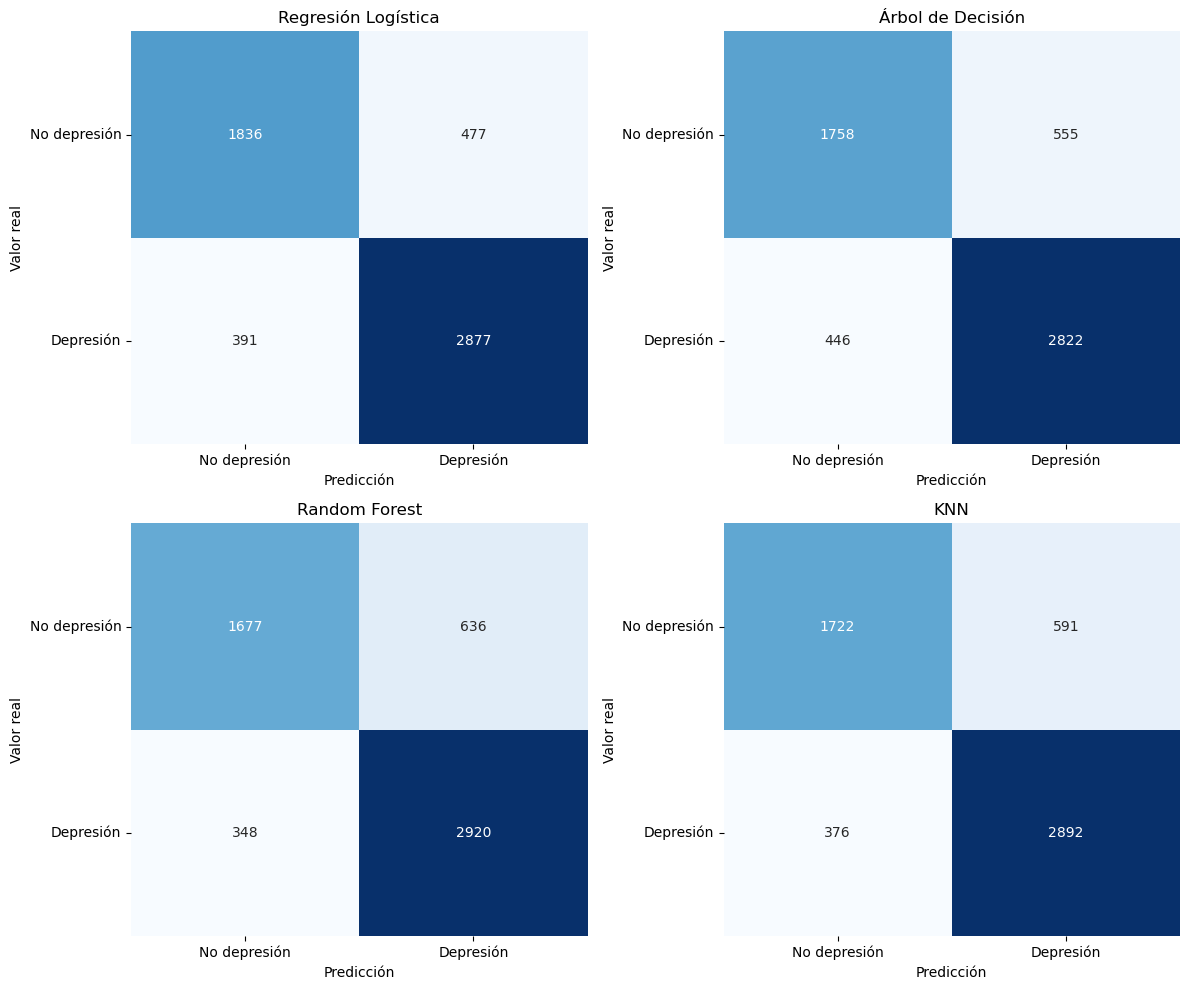

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["No depresión", "Depresión"])
    ax.set_yticklabels(["No depresión", "Depresión"], rotation=0)

plt.tight_layout()
plt.show()

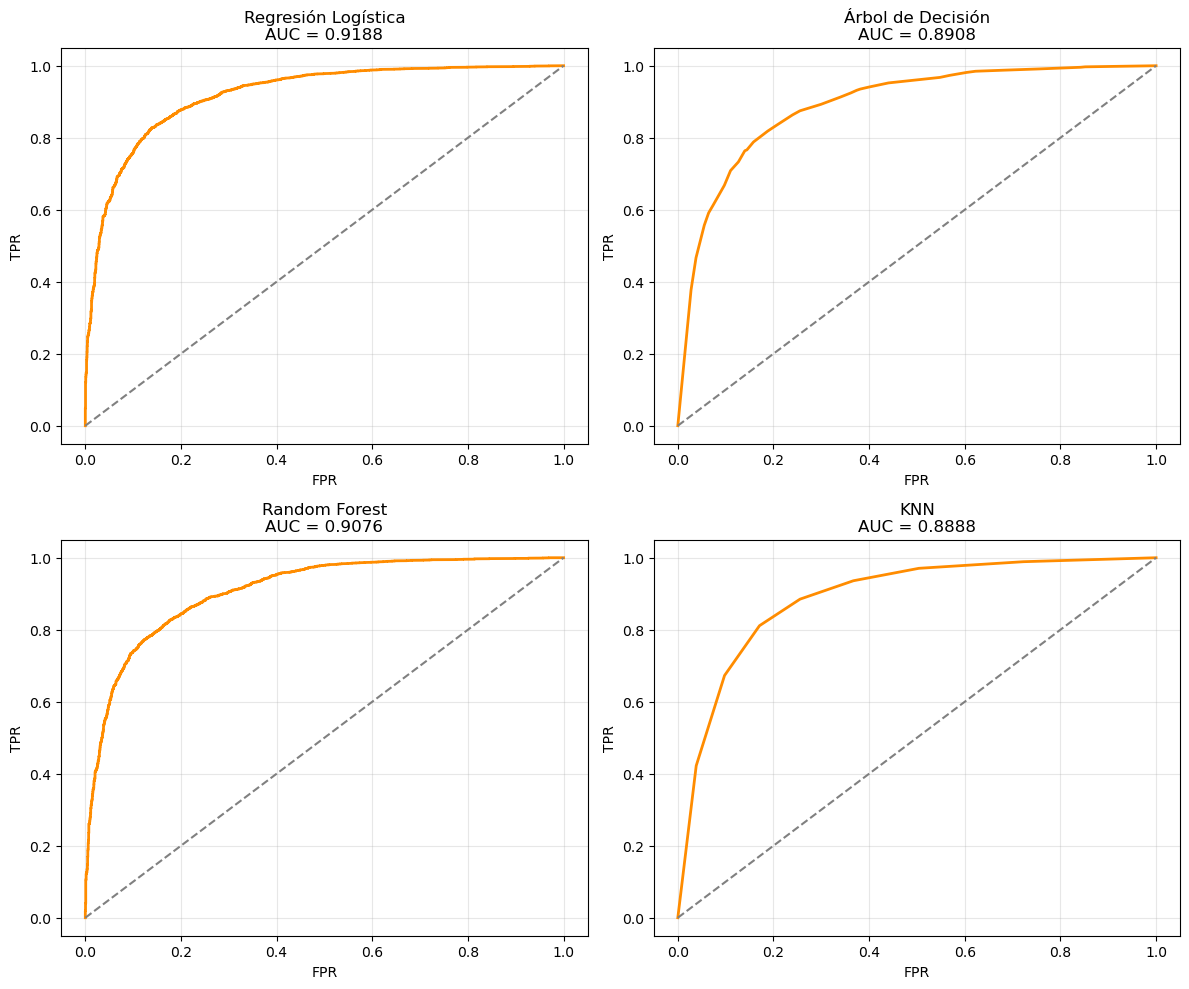

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, y_prob) in zip(axes, probabilities.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_value = roc_auc_score(y_test, y_prob)
    
    ax.plot(fpr, tpr, linewidth=2, color="darkorange")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(f"{name}\nAUC = {auc_value:.4f}")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
report_tables = []

for name, report in classification_reports.items():
    report_df = pd.DataFrame(report).transpose().reset_index()
    report_df.insert(0, "Modelo", name)
    report_tables.append(report_df)

reports_df = pd.concat(report_tables, ignore_index=True)

display(Markdown("## Reportes de clasificación"))
display(
    reports_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)

## Reportes de clasificación

,Modelo,index,precision,recall,f1-score,support
0,Regresión Logística,0,0.8244,0.7938,0.8088,2313
1,Regresión Logística,1,0.8578,0.8804,0.8689,3268
2,Regresión Logística,accuracy,0.8445,0.8445,0.8445,1
3,Regresión Logística,macro avg,0.8411,0.8371,0.8389,5581
4,Regresión Logística,weighted avg,0.8440,0.8445,0.8440,5581
5,Árbol de Decisión,0,0.7976,0.7601,0.7784,2313
6,Árbol de Decisión,1,0.8357,0.8635,0.8494,3268
7,Árbol de Decisión,accuracy,0.8206,0.8206,0.8206,1
8,Árbol de Decisión,macro avg,0.8166,0.8118,0.8139,5581
9,Árbol de Decisión,weighted avg,0.8199,0.8206,0.8199,5581


In [8]:
best_model_name = results_df.iloc[0]["Modelo"]
best_model = models[best_model_name]

display(Markdown(f"## Modelo final seleccionado: **{best_model_name}**"))

## Modelo final seleccionado: **Regresión Logística**

In [9]:
if best_model_name == "Regresión Logística":
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    coefs = best_model.named_steps["model"].coef_[0]
    
    coef_df = pd.DataFrame({
        "Variable": feature_names,
        "Coeficiente": coefs
    }).sort_values("Coeficiente", ascending=False)
    
    display(Markdown("## Variables con mayor efecto positivo"))
    display(coef_df.head(10))
    
    display(Markdown("## Variables con mayor efecto negativo"))
    display(coef_df.tail(10))

## Variables con mayor efecto positivo

,Variable,Coeficiente
18,cat__have_you_ever_had_suicidal_thoughts__Yes,1.293153
1,num__academic_pressure,1.165900
5,num__financial_stress,0.814050
16,cat__dietary_habits_Unhealthy,0.570693
4,num__work_study_hours,0.437496
10,cat__sleep_duration_Less than 5 hours,0.351154
33,cat__degree_grouped_LLB,0.255995
58,cat__city_grouped_Kolkata,0.233412
53,cat__city_grouped_Hyderabad,0.232142
47,cat__city_grouped_Ahmedabad,0.230412


## Variables con mayor efecto negativo

,Variable,Coeficiente
32,cat__degree_grouped_Class 12,-0.198517
11,cat__sleep_duration_More than 8 hours,-0.257448
55,cat__city_grouped_Jaipur,-0.259538
46,cat__city_grouped_Agra,-0.288531
3,num__study_satisfaction,-0.323573
62,cat__city_grouped_Mumbai,-0.347930
63,cat__city_grouped_Nagpur,-0.390554
13,cat__dietary_habits_Healthy,-0.517061
0,num__age,-0.593301
17,cat__have_you_ever_had_suicidal_thoughts__No,-1.220341


In [10]:
best_pred = predictions[best_model_name]
best_prob = probabilities[best_model_name]

errores_df = X_test.copy()
errores_df["real"] = y_test.values
errores_df["prediccion"] = best_pred
errores_df["probabilidad"] = best_prob
errores_df["tipo_error"] = np.where(
    (errores_df["real"] == 1) & (errores_df["prediccion"] == 0), "Falso negativo",
    np.where(
        (errores_df["real"] == 0) & (errores_df["prediccion"] == 1), "Falso positivo",
        "Correcto"
    )
)

display(Markdown("## Resumen de errores del mejor modelo"))
display(errores_df["tipo_error"].value_counts().to_frame("cantidad"))

## Resumen de errores del mejor modelo

,cantidad
tipo_error,
Correcto,4713
Falso positivo,477
Falso negativo,391


In [11]:
display(Markdown("## Ejemplos de falsos negativos"))
display(errores_df[errores_df["tipo_error"] == "Falso negativo"].head(10))

display(Markdown("## Ejemplos de falsos positivos"))
display(errores_df[errores_df["tipo_error"] == "Falso positivo"].head(10))

## Ejemplos de falsos negativos

,gender,age,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,have_you_ever_had_suicidal_thoughts_,work_study_hours,financial_stress,family_history_of_mental_illness,degree_grouped,city_grouped,real,prediccion,probabilidad,tipo_error
4,Male,29.0,3.0,6.63,2.0,7-8 hours,Moderate,Yes,6.0,1.0,No,B.Com,Kanpur,1,0,0.379480,Falso negativo
15,Male,28.0,3.0,7.10,1.0,5-6 hours,Moderate,Yes,1.0,2.0,No,Class 12,Meerut,1,0,0.479386,Falso negativo
22,Female,20.0,4.0,6.16,5.0,7-8 hours,Healthy,No,0.0,3.0,Yes,Class 12,Pune,1,0,0.138806,Falso negativo
34,Male,20.0,2.0,6.99,3.0,More than 8 hours,Unhealthy,No,6.0,3.0,Yes,Class 12,Vadodara,1,0,0.191624,Falso negativo
68,Male,20.0,1.0,7.90,4.0,7-8 hours,Moderate,Yes,6.0,1.0,Yes,Class 12,Visakhapatnam,1,0,0.217578,Falso negativo
99,Male,24.0,3.0,6.79,2.0,More than 8 hours,Healthy,Yes,8.0,1.0,Yes,MSc,Surat,1,0,0.476895,Falso negativo
110,Male,29.0,1.0,8.00,4.0,More than 8 hours,Unhealthy,Yes,5.0,3.0,No,MBBS,Rajkot,1,0,0.275498,Falso negativo
127,Male,24.0,2.0,8.58,5.0,5-6 hours,Healthy,Yes,6.0,2.0,No,LLB,Thane,1,0,0.309274,Falso negativo
149,Female,27.0,3.0,5.16,4.0,5-6 hours,Moderate,No,10.0,1.0,No,B.Arch,Rajkot,1,0,0.066472,Falso negativo
152,Male,31.0,3.0,8.08,4.0,More than 8 hours,Unhealthy,Yes,7.0,1.0,No,BSc,Other,1,0,0.445709,Falso negativo


## Ejemplos de falsos positivos

,gender,age,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,have_you_ever_had_suicidal_thoughts_,work_study_hours,financial_stress,family_history_of_mental_illness,degree_grouped,city_grouped,real,prediccion,probabilidad,tipo_error
1,Male,31.0,2.0,7.22,4.0,5-6 hours,Moderate,Yes,8.0,5.0,Yes,LLB,Meerut,0,1,0.779822,Falso positivo
7,Male,30.0,4.0,9.21,1.0,Less than 5 hours,Unhealthy,Yes,9.0,1.0,No,B.Ed,Patna,0,1,0.897617,Falso positivo
23,Male,25.0,4.0,9.41,3.0,More than 8 hours,Healthy,Yes,9.0,5.0,No,B.Ed,Patna,0,1,0.946949,Falso positivo
43,Male,25.0,3.0,5.65,2.0,More than 8 hours,Unhealthy,Yes,11.0,3.0,No,BE,Lucknow,0,1,0.890730,Falso positivo
44,Male,32.0,4.0,7.25,3.0,Less than 5 hours,Moderate,Yes,9.0,5.0,No,MCA,Lucknow,0,1,0.947064,Falso positivo
69,Female,31.0,2.0,6.86,3.0,Less than 5 hours,Unhealthy,Yes,6.0,5.0,Yes,MCA,Nagpur,0,1,0.809636,Falso positivo
72,Female,29.0,5.0,7.80,2.0,Less than 5 hours,Healthy,Yes,7.0,1.0,Yes,MA,Kalyan,0,1,0.825725,Falso positivo
73,Male,33.0,3.0,9.95,5.0,Less than 5 hours,Unhealthy,Yes,3.0,4.0,No,MBBS,Kanpur,0,1,0.739297,Falso positivo
74,Female,29.0,4.0,7.80,3.0,Less than 5 hours,Moderate,Yes,11.0,1.0,Yes,B.Ed,Ludhiana,0,1,0.818252,Falso positivo
78,Male,33.0,4.0,10.00,3.0,More than 8 hours,Healthy,Yes,10.0,4.0,Yes,BSc,Patna,0,1,0.876769,Falso positivo


## Interpretación de resultados

La evaluación comparativa muestra que los modelos presentan comportamientos distintos frente al problema de clasificación. Aunque el accuracy ofrece una visión general del porcentaje de aciertos, en este caso se dio mayor importancia al recall y al F1-score, debido a que el interés principal es identificar correctamente los casos positivos de depresión.

La matriz de confusión permitió analizar el tipo de errores cometidos por cada modelo, especialmente los falsos negativos, que representan estudiantes con depresión no detectados. Por su parte, la curva ROC permitió comparar la capacidad de discriminación de los modelos a distintos umbrales de decisión.

Finalmente, el modelo seleccionado se eligió no solo por su desempeño global, sino también por su utilidad interpretativa y su capacidad para apoyar decisiones analíticas dentro del contexto del problema.

## Conclusiones

En esta fase se evaluaron los cuatro modelos de clasificación entrenados previamente, utilizando métricas adecuadas para clasificación binaria, matrices de confusión y curvas ROC. Esta evaluación permitió identificar diferencias en desempeño entre los modelos y seleccionar el más adecuado para el problema de predicción de depresión en estudiantes.

Además, se interpretaron los resultados del modelo final a partir de la importancia de variables o coeficientes, así como del análisis de errores de clasificación. Esto permitió no solo elegir el mejor modelo, sino también comprender mejor qué variables influyen en la predicción y qué limitaciones presenta el sistema.